In [1]:
# Dubins car — reach-avoid MPC with certificate-based terminal set

In [2]:
# ── Load computed certificate + controller ────────────────────────────────────
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca

from sop_bounded_control_unconstrained_controller_20260315_185542 import (
    u_opt,
    certificate_opt,
    k1_opt,
)

u_opt = sp.Matrix(u_opt)
k1_opt = sp.Matrix(k1_opt)

# ── Symbolic variables ────────────────────────────────────────────────────────
x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, th, v]

# ── Dubins-car dynamics ───────────────────────────────────────────────────────
f_sym = sp.Matrix([v * sp.cos(th), v * sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
hx = sp.Matrix([x1, x2])

# ── Sets in output (y) space ─────────────────────────────────────────────────
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_set_y = (y2 - 0) ** 2 + (2 * (y1 + 1.7)) ** 2 - 0.4
alpha = 1e-3 * (-target_set_y + 300)
safe_set_y = alpha * h_raw

safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

# ── Numpy callables ───────────────────────────────────────────────────────────
certificate_func = sp.lambdify(state_vars, certificate_opt, "numpy")
safe_set_y_func = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_set_y_func = sp.lambdify([y1, y2], target_set_y, "numpy")
safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")
target_set_x_func = sp.lambdify(state_vars, target_set_x, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")

print("Certificate symbols :", certificate_opt.free_symbols)
print("u_opt symbols       :", u_opt[0].free_symbols)

Certificate symbols : {x1, th, x2, v}
u_opt symbols       : {x2, x1, v, th}


In [3]:
# ── SymPy → CasADi converter (polynomials only; no trig in certificate) ───────
def sympy2casadi(expr, sym_map):
    """Recursively convert a SymPy polynomial expression to CasADi SX."""
    if isinstance(
        expr,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(expr)
    elif isinstance(expr, sp.Symbol):
        return sym_map[expr]
    elif isinstance(expr, sp.Add):
        return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        result = 1.0
        for a in expr.args:
            result = result * sympy2casadi(a, sym_map)
        return result
    elif isinstance(expr, sp.Pow):
        return sympy2casadi(expr.args[0], sym_map) ** sympy2casadi(
            expr.args[1], sym_map
        )
    elif isinstance(expr, sp.sin):
        return ca.sin(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.cos):
        return ca.cos(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.Number):
        return float(expr)
    else:
        raise ValueError(f"Unsupported sympy type: {type(expr)}  --  {expr}")


# ── CasADi SX symbols matching state_vars = [x1, x2, th, v] ─────────────────
ca_x1 = ca.SX.sym("x1")
ca_x2 = ca.SX.sym("x2")
ca_th = ca.SX.sym("th")
ca_v = ca.SX.sym("v")
sym_map = {x1: ca_x1, x2: ca_x2, th: ca_th, v: ca_v}

cert_ca_expr = sympy2casadi(certificate_opt, sym_map)
safe_ca_expr = sympy2casadi(safe_set_x, sym_map)

cert_ca_f = ca.Function("cert", [ca_x1, ca_x2, ca_th, ca_v], [cert_ca_expr])
safe_ca_f = ca.Function("safe", [ca_x1, ca_x2, ca_th, ca_v], [safe_ca_expr])


# Wrappers that accept a length-4 CasADi vector
def cert_vec(xv):
    return cert_ca_f(xv[0], xv[1], xv[2], xv[3])


def safe_vec(xv):
    return safe_ca_f(xv[0], xv[1], xv[2], xv[3])


# ── Sanity check ──────────────────────────────────────────────────────────────
test_x = np.array([0.5, 0.5, 3.5, 0.3])
v_sp = float(certificate_opt.subs(dict(zip(state_vars, test_x))))
v_ca = float(cert_ca_f(*test_x))
s_sp = float(safe_set_x.subs(dict(zip(state_vars, test_x))))
s_ca = float(safe_ca_f(*test_x))
print(f"Certificate:  sympy={v_sp:.6f}  casadi={v_ca:.6f}  diff={abs(v_sp-v_ca):.2e}")
print(f"Safe set:     sympy={s_sp:.6f}  casadi={s_ca:.6f}  diff={abs(s_sp-s_ca):.2e}")
assert abs(v_sp - v_ca) < 1e-4 and abs(s_sp - s_ca) < 1e-4, "Conversion mismatch!"
print("Conversions verified OK.")

Certificate:  sympy=-17.722973  casadi=-17.722973  diff=0.00e+00
Safe set:     sympy=-17.272972  casadi=-17.272972  diff=0.00e+00
Conversions verified OK.


In [4]:
# ── MPC problem: reach-avoid with certificate-based terminal set ──────────────
#
#   min   sum_k  ||h(x_k) - y_target||^2_Q  +  0.05*||u_k||^2
#           + 100 * ||h(x_N) - y_target||^2_Qf
#   s.t.  x_{k+1} = RK4(x_k, u_k)               (dynamics)
#         safe_vec(x_k) >= 0   ∀ k=0…N           (stay safe)
#         cert_vec(x_N) >= 0                      (terminal: inside certificate
#                                                  zero-superlevel set V≥0)
#         |u1| ≤ u1_max,  |u2| ≤ u2_max           (control bounds)
#
#   Terminal set V(x_N)≥0 guarantees the controller can steer to the target
#   once inside (by the certificate construction).

dt_mpc = 0.1
N_hor = 20
u1_max = 3.0
u2_max = 2.0
TARGET_POS = np.array([-1.7, 0.0])

# ── CasADi continuous dynamics ───────────────────────────────────────────────
xc = ca.SX.sym("x", 4)
uc = ca.SX.sym("u", 2)
fc = ca.vertcat(xc[3] * ca.cos(xc[2]), xc[3] * ca.sin(xc[2]), uc[0], uc[1])
rhs_ca = ca.Function("f", [xc, uc], [fc])

k1_ = rhs_ca(xc, uc)
k2_ = rhs_ca(xc + dt_mpc / 2 * k1_, uc)
k3_ = rhs_ca(xc + dt_mpc / 2 * k2_, uc)
k4_ = rhs_ca(xc + dt_mpc * k3_, uc)
x_next_expr = xc + (dt_mpc / 6) * (k1_ + 2 * k2_ + 2 * k3_ + k4_)
F_disc = ca.Function("F_disc", [xc, uc], [x_next_expr])


def h_ca(xv):
    """Output map h(x) = [x1, x2]."""
    return ca.vertcat(xv[0], xv[1])


_IPOPT_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}


def solve_mpc(x0_val, U_warm=None):
    """
    Solve the reach-avoid MPC from x0_val.

    Terminal constraint : cert_vec(x_N) >= 0  (certificate zero-superlevel set)
    Safety constraint   : safe_vec(x_k) >= 0  for all k

    Returns (feasible: bool, U_opt: ndarray(2,N_hor) or None)
    """
    opti = ca.Opti()
    X_var = opti.variable(4, N_hor + 1)
    U_var = opti.variable(2, N_hor)

    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X_var[:, 0] == x0_np)

    # Dynamics + safety along horizon
    for k in range(N_hor):
        opti.subject_to(X_var[:, k + 1] == F_disc(X_var[:, k], U_var[:, k]))
        opti.subject_to(safe_vec(X_var[:, k]) >= 0)
    opti.subject_to(safe_vec(X_var[:, N_hor]) >= 0)

    # ── Terminal constraint: V(x_N) >= 0  ────────────────────────────────────
    opti.subject_to(cert_vec(X_var[:, N_hor]) >= 0)

    # Control bounds
    opti.subject_to(opti.bounded(-u1_max, U_var[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U_var[1, :], u2_max))

    # Cost: output tracking (stage + terminal) + control effort
    tgt = ca.DM(TARGET_POS)
    Q_y = ca.DM([[5.0, 0], [0, 5.0]])
    Qf_y = ca.DM([[80.0, 0], [0, 80.0]])
    R_u = ca.DM([[0.05, 0], [0, 0.05]])
    cost = 0
    for k in range(N_hor):
        dy = h_ca(X_var[:, k]) - tgt
        cost += dy.T @ Q_y @ dy + U_var[:, k].T @ R_u @ U_var[:, k]
    dy_N = h_ca(X_var[:, N_hor]) - tgt
    cost += dy_N.T @ Qf_y @ dy_N
    opti.minimize(cost)

    # ── Warm start ────────────────────────────────────────────────────────────
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        X_ws = np.zeros((4, N_hor + 1))
        X_ws[:, 0] = x0_np
        for k in range(N_hor):
            xk, uk = X_ws[:, k], U_ws[:, k]
            X_ws[:, k + 1] = xk + dt_mpc * np.array(
                [xk[3] * np.cos(xk[2]), xk[3] * np.sin(xk[2]), uk[0], uk[1]]
            )
        opti.set_initial(X_var, X_ws)
        opti.set_initial(U_var, U_ws)
    else:
        tgt_full = np.array([TARGET_POS[0], TARGET_POS[1], x0_np[2], 0.0])
        X_ws = np.array(
            [(1 - k / N_hor) * x0_np + (k / N_hor) * tgt_full for k in range(N_hor + 1)]
        ).T
        opti.set_initial(X_var, X_ws)
        opti.set_initial(U_var, 0)

    opti.solver("ipopt", _IPOPT_OPTS)
    try:
        sol = opti.solve()
        return True, sol.value(U_var)
    except Exception:
        return False, None


print(f"RA-MPC ready: N_hor={N_hor}, dt={dt_mpc}s, " f"u_bounds=[±{u1_max}, ±{u2_max}]")
print("Terminal constraint: cert_vec(x_N) >= 0  (V(x) zero-superlevel set)")

RA-MPC ready: N_hor=20, dt=0.1s, u_bounds=[±3.0, ±2.0]
Terminal constraint: cert_vec(x_N) >= 0  (V(x) zero-superlevel set)


In [5]:
# ── Sample (same seed/bounds as other notebooks) + MPC feasibility check ──────
N_samples = 500
np.random.seed(42)

lower_bound = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
upper_bound = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])

x_samples = np.random.rand(4, N_samples) * (upper_bound - lower_bound).reshape(
    -1, 1
) + lower_bound.reshape(-1, 1)

safe_vals = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))

# Candidates: inside safe set AND outside target set
candidate_mask = (safe_vals >= 0) & (target_vals > 0)
candidate_idx = np.where(candidate_mask)[0]
print(f"Total samples : {N_samples}")
print(f"Candidates (safe & outside target): {len(candidate_idx)}")

# ── Parallel first-step MPC feasibility check ─────────────────────────────────
from joblib import Parallel, delayed


def _check_one(idx):
    ok, _ = solve_mpc(x_samples[:, idx])
    return idx, ok


print(
    f"\nChecking RA-MPC feasibility ({len(candidate_idx)} candidates, "
    f"N_hor={N_hor}, dt={dt_mpc}s, terminal: V(x_N)≥0) ..."
)

results = Parallel(n_jobs=-1, prefer="processes", verbose=5)(
    delayed(_check_one)(idx) for idx in candidate_idx
)

mpc_feasible_idx = np.array([idx for idx, ok in results if ok])
mpc_infeasible_idx = np.array([idx for idx, ok in results if not ok])

n_c = len(candidate_idx)
print(
    f"\nRA-MPC feasible:   {len(mpc_feasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_feasible_idx)/n_c:.1f}%)"
)
print(
    f"RA-MPC infeasible: {len(mpc_infeasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_infeasible_idx)/n_c:.1f}%)"
)

Total samples : 500
Candidates (safe & outside target): 226

Checking RA-MPC feasibility (226 candidates, N_hor=20, dt=0.1s, terminal: V(x_N)≥0) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public Lic

[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 207 out of 226 | elapsed:    3.2s remaining:    0.3s



RA-MPC feasible:   212 / 226  (93.8%)
RA-MPC infeasible:  14 / 226  (6.2%)


[Parallel(n_jobs=-1)]: Done 226 out of 226 | elapsed:    3.4s finished


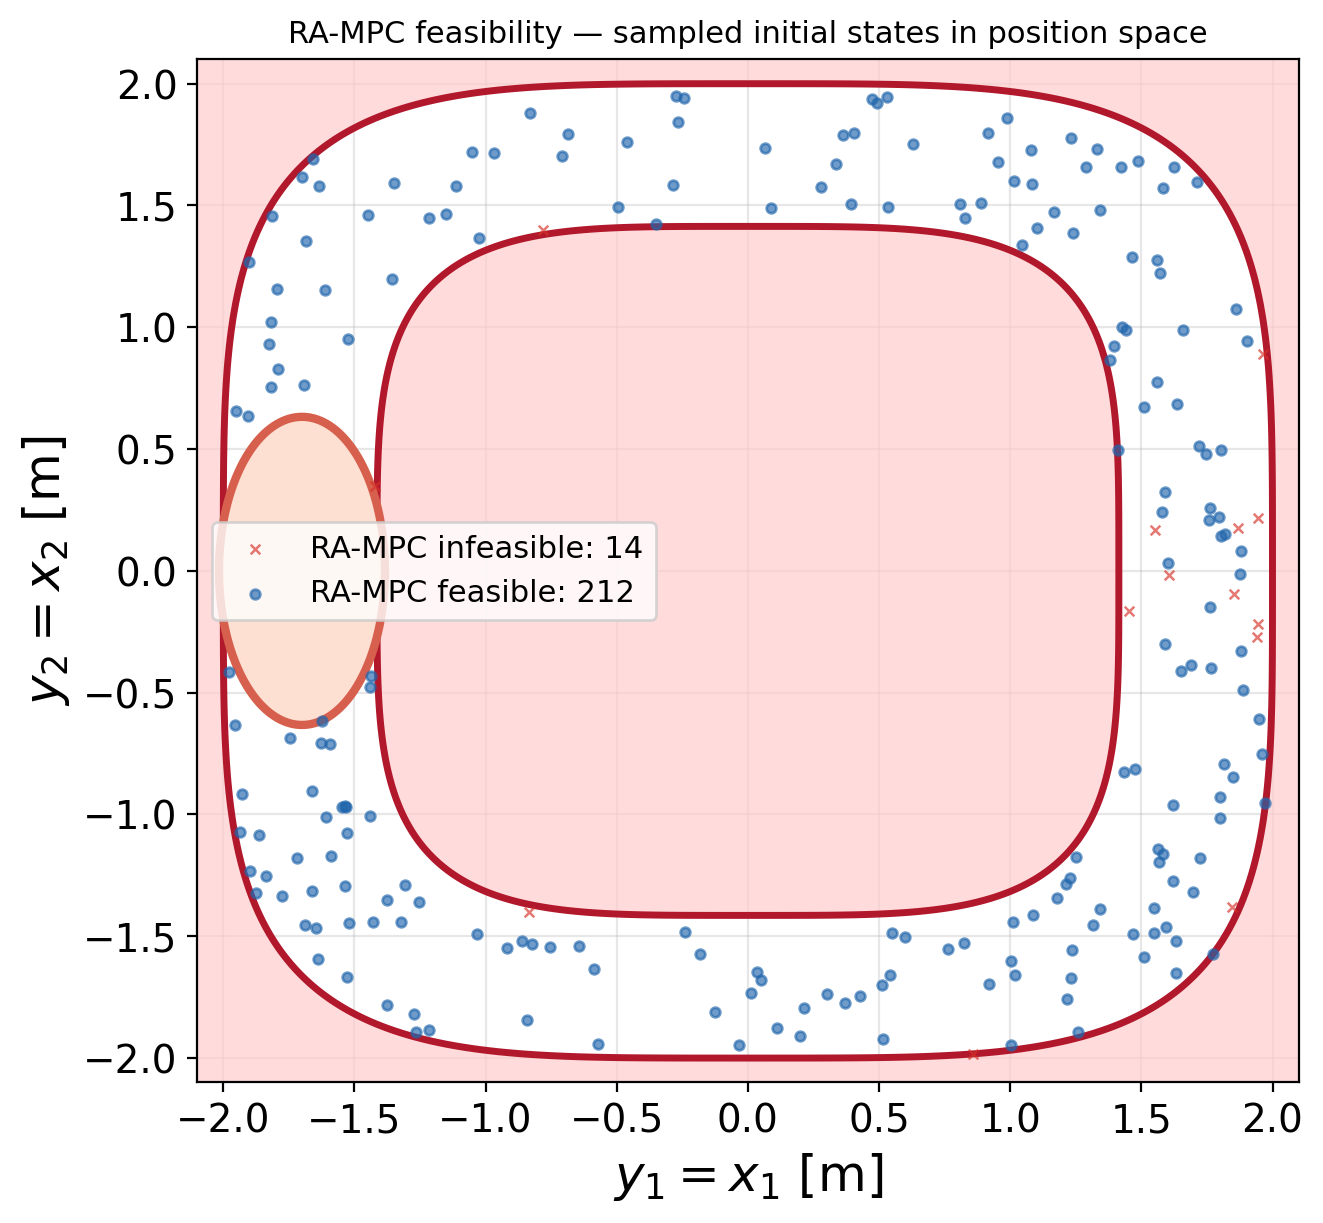

In [6]:
# ── Visualise RA-MPC feasible / infeasible initial states ─────────────────────
from functional import BetterColor

y_feasible = np.array(hx_func(*x_samples[:, mpc_feasible_idx])).reshape(2, -1)
y_infeasible = np.array(hx_func(*x_samples[:, mpc_infeasible_idx])).reshape(2, -1)

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

ax.contourf(
    Y1, Y2, Z_safe, levels=[-np.inf, 0], colors=["#ffcccc"], alpha=0.7, zorder=2
)
ax.contour(Y1, Y2, Z_safe, levels=[0], colors=["#b2182b"], linewidths=2.5, zorder=3)
ax.contourf(
    Y1, Y2, Z_target, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=4
)
ax.contour(Y1, Y2, Z_target, levels=[0], colors=["#d6604d"], linewidths=3, zorder=5)

ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=12,
    color="#d73027",
    alpha=0.65,
    marker="x",
    linewidths=0.9,
    label=f"RA-MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=9,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=12,
    color="#2166ac",
    alpha=0.65,
    marker="o",
    label=f"RA-MPC feasible: {len(mpc_feasible_idx)}",
    zorder=10,
)

fs = 22
ax.set_xlabel("$y_1 = x_1$ [m]", fontsize=fs - 4)
ax.set_ylabel("$y_2 = x_2$ [m]", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title(
    "RA-MPC feasibility — sampled initial states in position space", fontsize=11
)
plt.show()

In [7]:
# ── Receding-horizon RA-MPC simulation ────────────────────────────────────────
from scipy.integrate import solve_ivp

T_max = 30.0
T_min = 0.2
phi_tol = 0.05


def simulate_ra_mpc_traj(x0):
    """Simulate one trajectory under the receding-horizon RA-MPC."""
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0
    U_prev = None

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0:
            break

        ok, U_opt = solve_mpc(x, U_warm=U_prev)
        if not ok:
            break

        u0 = np.array(U_opt[:, 0]).flatten()
        U_prev = U_opt

        def rhs(_, x_):
            return [
                x_[3] * np.cos(x_[2]),
                x_[3] * np.sin(x_[2]),
                float(u0[0]),
                float(u0[1]),
            ]

        sol = solve_ivp(
            rhs,
            [t, t + dt_mpc],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt_mpc / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break

        x = sol.y[:, -1]
        t += dt_mpc
        xs.append(x.copy())
        ts.append(t)

    ts = np.array(ts)
    xs = np.array(xs)
    ys = np.array(hx_func(*xs.T)).reshape(2, -1).T
    return ts, xs, ys


# Simulate a batch; filter afterwards to keep 5 good trajectories
N_sim_try = min(15, len(mpc_feasible_idx))
x_sim = x_samples[:, mpc_feasible_idx[:N_sim_try]]

raw = []
for i in range(N_sim_try):
    print(f"  [{i+1:2d}/{N_sim_try}] ", end="", flush=True)
    res = simulate_ra_mpc_traj(x_sim[:, i])
    raw.append(res)
    tt, tx, _ = res
    phi_f = float(np.squeeze(target_set_x_func(*tx[-1])))
    print(f"T={tt[-1]:.2f}s  {'REACHED' if phi_f<=0 else f'phi={phi_f:.4f}'}")

traj_t = [r[0] for r in raw]
traj_x = [r[1] for r in raw]
traj_y = [r[2] for r in raw]

  [ 1/15] 
******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

T=1.10s  phi=35.3653
  [ 2/15] T=0.90s  REACHED
  [ 3/15] T=2.00s  REACHED
  [ 4/15] T=1.10s  phi=3.6681
  [ 5/15] T=0.90s  phi=32.9762
  [ 6/15] T=1.70s  REACHED
  [ 7/15] T=0.50s  phi=2.4624
  [ 8/15] T=1.00s  REACHED
  [ 9/15] T=0.90s  REACHED
  [10/15] T=2.10s  REACHED
  [11/15] T=0.10s  REACHED
  [12/15] T=1.50s  REACHED
  [13/15] T=0.90s  phi=3.9500
  [14/15] T=1.00s  REACHED
  [15/15] T=1.50s  phi=31.8050


Kept 1/15 trajectories  (removed 14: hit T_max or did not reach target)


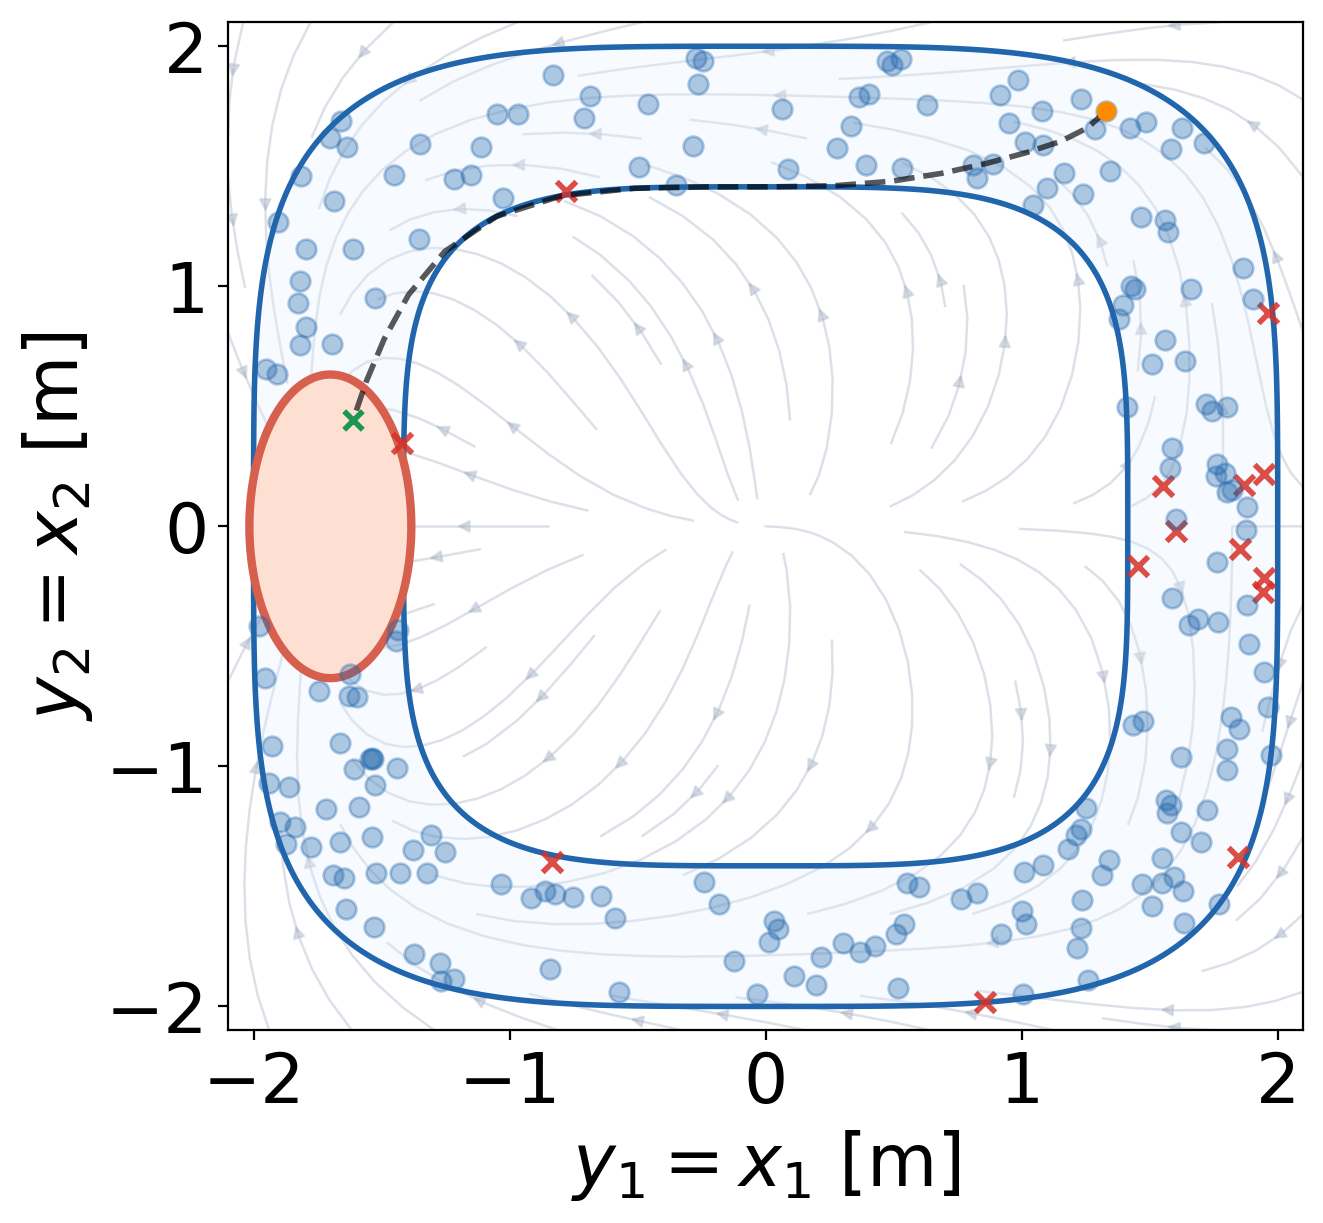

In [9]:
# ── Filter + visualise trajectories (same style as unconstrained notebook) ────
# Style mirrors example_dubins_car_unconstrained_reach_avoid.ipynb cell 8:
#   - fs=30 tick labels, fs-4 axis labels
#   - unsafe region: #ffcccc fill / #b2182b boundary
#   - target region: #fee0d2 fill / #d6604d boundary
#   - trajectory: black dashed lw=2
#   - start: BetterColor.orange3() circle
#   - end:   BetterColor.green0() x

filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] < T_max - 1e-6
    and tt[-1] >= T_min
    and float(np.squeeze(target_set_x_func(*tx[-1]))) <= phi_tol
][2:3]

print(
    f"Kept {len(filtered)}/{len(traj_t)} trajectories  "
    f"(removed {len(traj_t)-len(filtered)}: hit T_max or did not reach target)"
)
traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

# ── Set contour grids ─────────────────────────────────────────────────────────
n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

# ── k1 vector field ───────────────────────────────────────────────────────────
k1_func = sp.lambdify([y1, y2], list(k1_opt), "numpy")
n_vf = 30
y1_vf = np.linspace(-2.1, 2.1, n_vf)
y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()
U_k1, V_k1 = k1_vals[0], k1_vals[1]

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# k1 streamlines (background)
ax.streamplot(
    y1_vf,
    y2_vf,
    U_k1,
    V_k1,
    color=BetterColor.gray0(0.45),
    linewidth=0.9,
    density=0.9,
    arrowsize=0.9,
    zorder=1,
)

# Safe / unsafe region
ax.contourf(
    Y1, Y2, Z_safe_y, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1, Y2, Z_safe_y, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_target_y, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

# Feasible / infeasible scatter
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=50,
    color="#d73027",
    alpha=0.85,
    marker="x",
    linewidths=2,
    label=f"RA-MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=8,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=50,
    color="#2166ac",
    alpha=0.35,
    marker="o",
    label=f"RA-MPC feasible: {len(mpc_feasible_idx)}",
    zorder=9,
)

# Trajectories
for ty in traj_y_plot:
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=2, alpha=0.65, linestyle="--", zorder=10
    )
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=45,
        c=[BetterColor.orange3()],
        marker="o",
        linewidths=0.4,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=45,
        c=[BetterColor.green0()],
        marker="x",
        linewidths=2.0,
        zorder=20,
    )

fs = 30
ax.set_xlabel("$y_1 = x_1$ [m]", fontsize=fs - 4)
ax.set_ylabel("$y_2 = x_2$ [m]", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
plt.show()

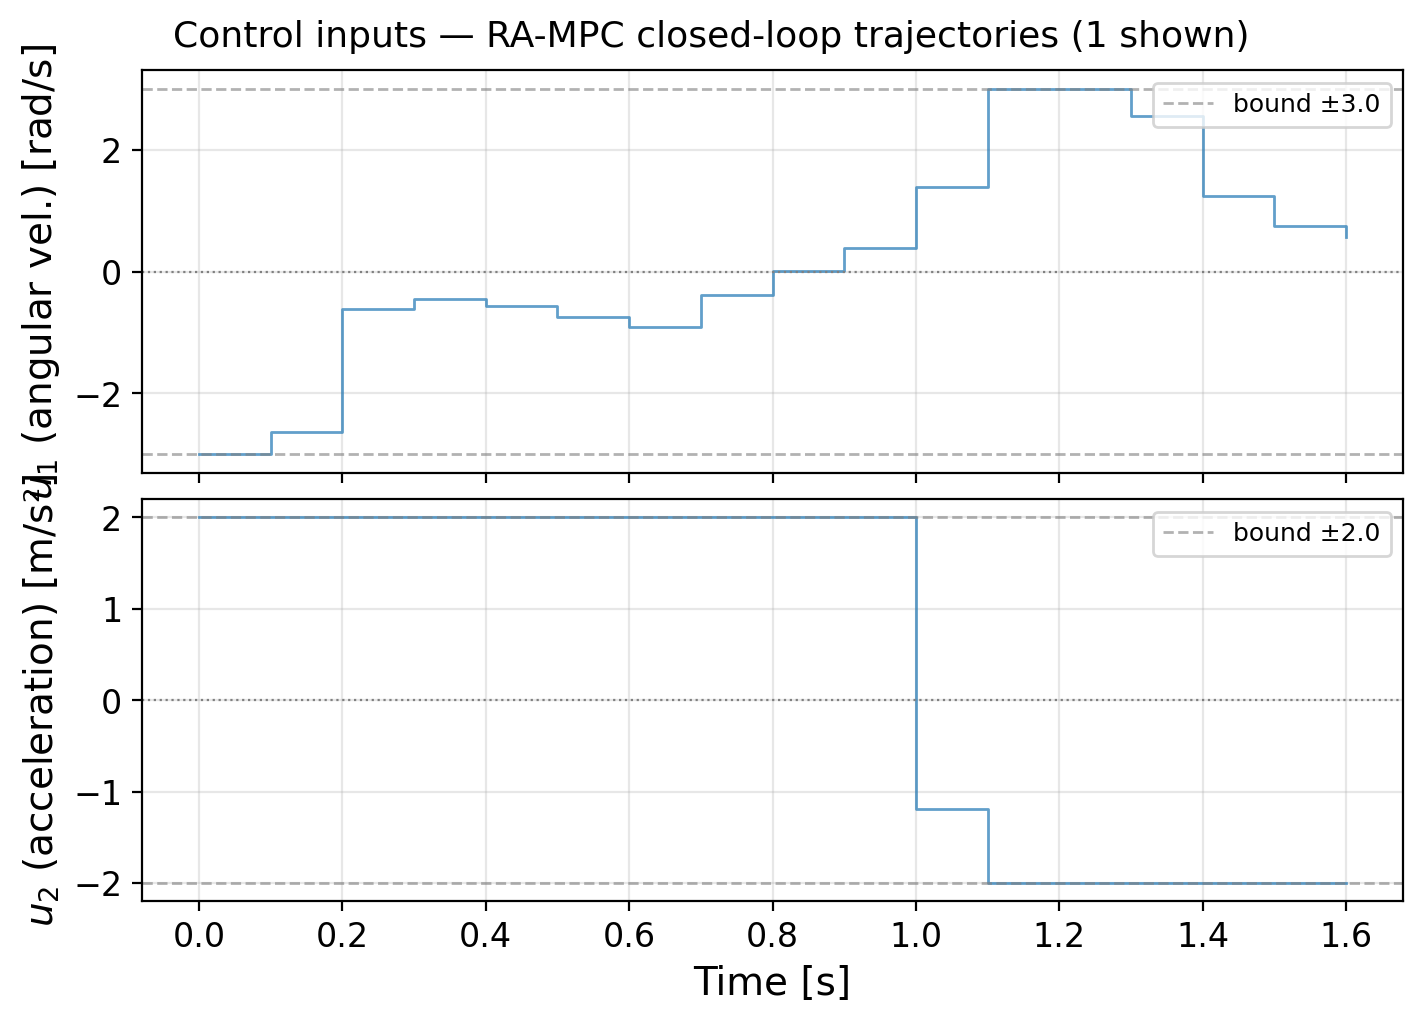

In [10]:
# ── Control inputs along the filtered trajectories ────────────────────────────
# RA-MPC holds u constant over each dt_mpc interval;
# recover u1 = dtheta/dt and u2 = dv/dt from the simulated states.

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tt, tx in zip(traj_t_plot, traj_x_plot):
    if len(tt) < 2:
        continue
    dt_arr = np.diff(tt)
    u1_approx = np.diff(tx[:, 2]) / dt_arr  # dtheta/dt ≈ u1
    u2_approx = np.diff(tx[:, 3]) / dt_arr  # dv/dt     ≈ u2
    axes[0].step(tt[:-1], u1_approx, lw=1.0, alpha=0.7, where="post")
    axes[1].step(tt[:-1], u2_approx, lw=1.0, alpha=0.7, where="post")

for ax, lbl, bnd in zip(
    axes,
    ["$u_1$ (angular vel.) [rad/s]", "$u_2$ (acceleration) [m/s\u00b2]"],
    [u1_max, u2_max],
):
    ax.axhline(
        bnd, color="gray", lw=1.0, ls="--", alpha=0.6, label=f"bound \u00b1{bnd}"
    )
    ax.axhline(-bnd, color="gray", lw=1.0, ls="--", alpha=0.6)
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.set_ylabel(lbl, fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[1].set_xlabel("Time [s]", fontsize=14)
fig.suptitle(
    f"Control inputs — RA-MPC closed-loop trajectories ({len(traj_t_plot)} shown)",
    fontsize=13,
)
plt.show()